<a href="https://colab.research.google.com/github/NatashaMyruta/Machine-Learning/blob/main/%D0%9B%D0%A06_%D0%9C%D0%9D_%D0%9C%D0%B8%D1%80%D1%83%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Мирута Наталія Романівна
ФІТ 3-15



In [ ]:
# Імпорт необхідних бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV  # Замість HalvingGridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Налаштування відображення
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("Бібліотеки успішно імпортовано!")

Бібліотеки успішно імпортовано!


In [ ]:
# Спосіб 1: Завантаження з комп'ютера
from google.colab import files
print("Завантажте файл diabetes_prediction_dataset.csv")
uploaded = files.upload()

# Читання даних
df = pd.read_csv('diabetes_prediction_dataset.csv')
print("Дані успішно завантажено!")
print(f"Розмір датасету: {df.shape}")

Завантажте файл diabetes_prediction_dataset.csv


Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv
Дані успішно завантажено!
Розмір датасету: (100000, 9)


In [ ]:
print("\n" + "="*60)
print("ПОПЕРЕДНІЙ АНАЛІЗ ДАНИХ")
print("="*60)

# Перші рядки
print("\nПерші 5 рядків:")
display(df.head())

# Інформація про датасет
print("\nІнформація про DataFrame:")
df.info()

# Статистичний опис
print("\nОписова статистика:")
display(df.describe())

# Перевірка пропущених даних
print("\nКількість пропущених значень:")
print(df.isnull().sum())

# Перевірка дублікатів
print(f"\nКількість дублікатів: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"Після видалення дублікатів: {df.shape}")

# Перевірка унікальних значень у категоріальних колонках
print("\nУнікальні значення в категоріальних колонках:")
categorical_cols = ['gender', 'smoking_history']
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")
    print(f"Розподіл:\n{df[col].value_counts()}")


ПОПЕРЕДНІЙ АНАЛІЗ ДАНИХ

Перші 5 рядків:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



Інформація про DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Описова статистика:


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000



Кількість пропущених значень:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Кількість дублікатів: 3854
Після видалення дублікатів: (96146, 9)

Унікальні значення в категоріальних колонках:

gender: ['Female' 'Male' 'Other']
Розподіл:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

smoking_history: ['never' 'No Info' 'current' 'former' 'ever' 'not current']
Розподіл:
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64



КОРЕЛЯЦІЙНИЙ АНАЛІЗ


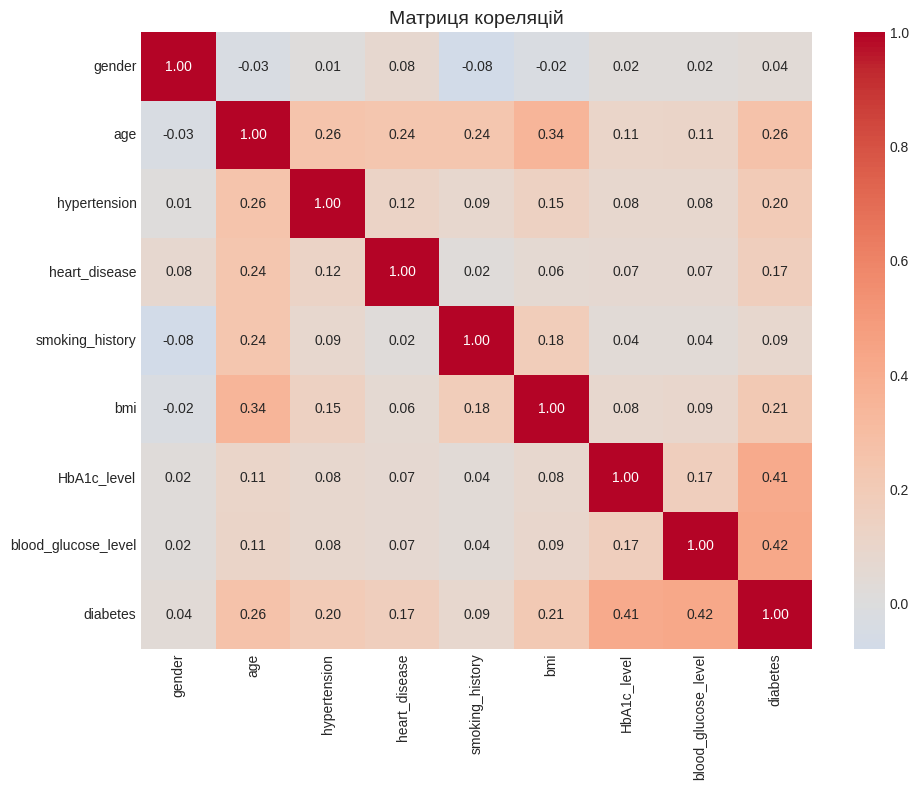


Кореляція з цільовою змінною (diabetes):
diabetes               1.000000
blood_glucose_level    0.424336
HbA1c_level            0.406408
age                    0.264927
bmi                    0.214932
hypertension           0.195710
heart_disease          0.170711
smoking_history        0.088471
gender                 0.037613
Name: diabetes, dtype: float64


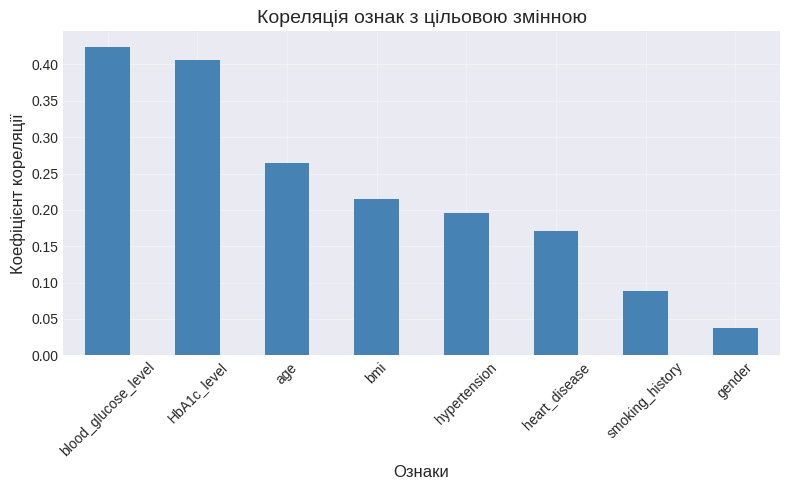

In [ ]:
print("\n" + "="*60)
print("КОРЕЛЯЦІЙНИЙ АНАЛІЗ")
print("="*60)

# Кодування категоріальних змінних для кореляції
df_encoded = df.copy()
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df_encoded['gender'] = le_gender.fit_transform(df_encoded['gender'])
df_encoded['smoking_history'] = le_smoking.fit_transform(df_encoded['smoking_history'])

# Матриця кореляцій
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Матриця кореляцій', fontsize=14)
plt.tight_layout()
plt.show()

# Кореляція з цільовою змінною
print("\nКореляція з цільовою змінною (diabetes):")
corr_with_target = correlation_matrix['diabetes'].sort_values(ascending=False)
print(corr_with_target)

# Візуалізація кореляції з цільовою змінною
plt.figure(figsize=(8, 5))
corr_with_target.drop('diabetes').plot(kind='bar', color='steelblue')
plt.title('Кореляція ознак з цільовою змінною', fontsize=14)
plt.xlabel('Ознаки', fontsize=12)
plt.ylabel('Коефіцієнт кореляції', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


АНАЛІЗ РОЗПОДІЛІВ ТА БАЛАНСУВАННЯ КЛАСІВ

Розподіл цільової змінної:
0 (немає діабету): 87664 (91.18%)
1 (є діабет): 8482 (8.82%)


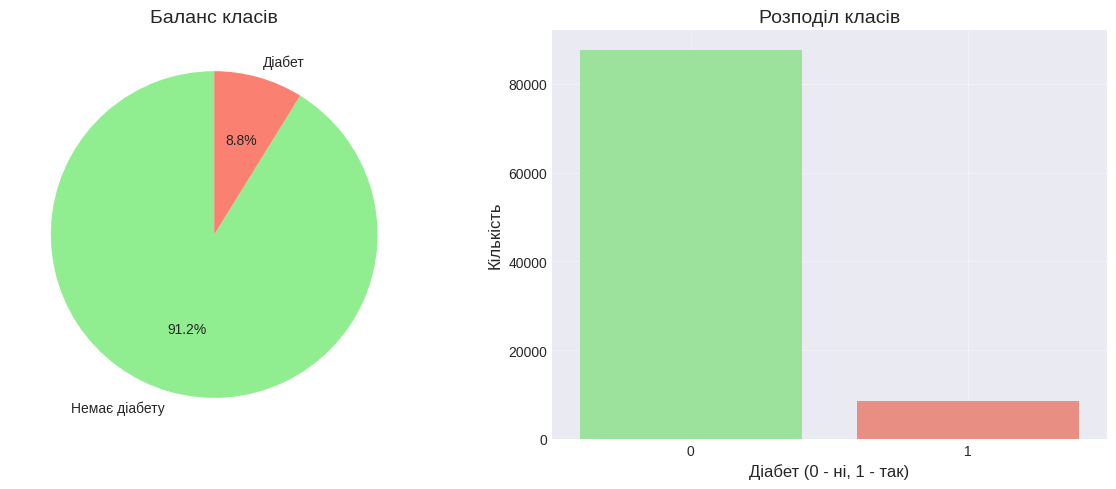

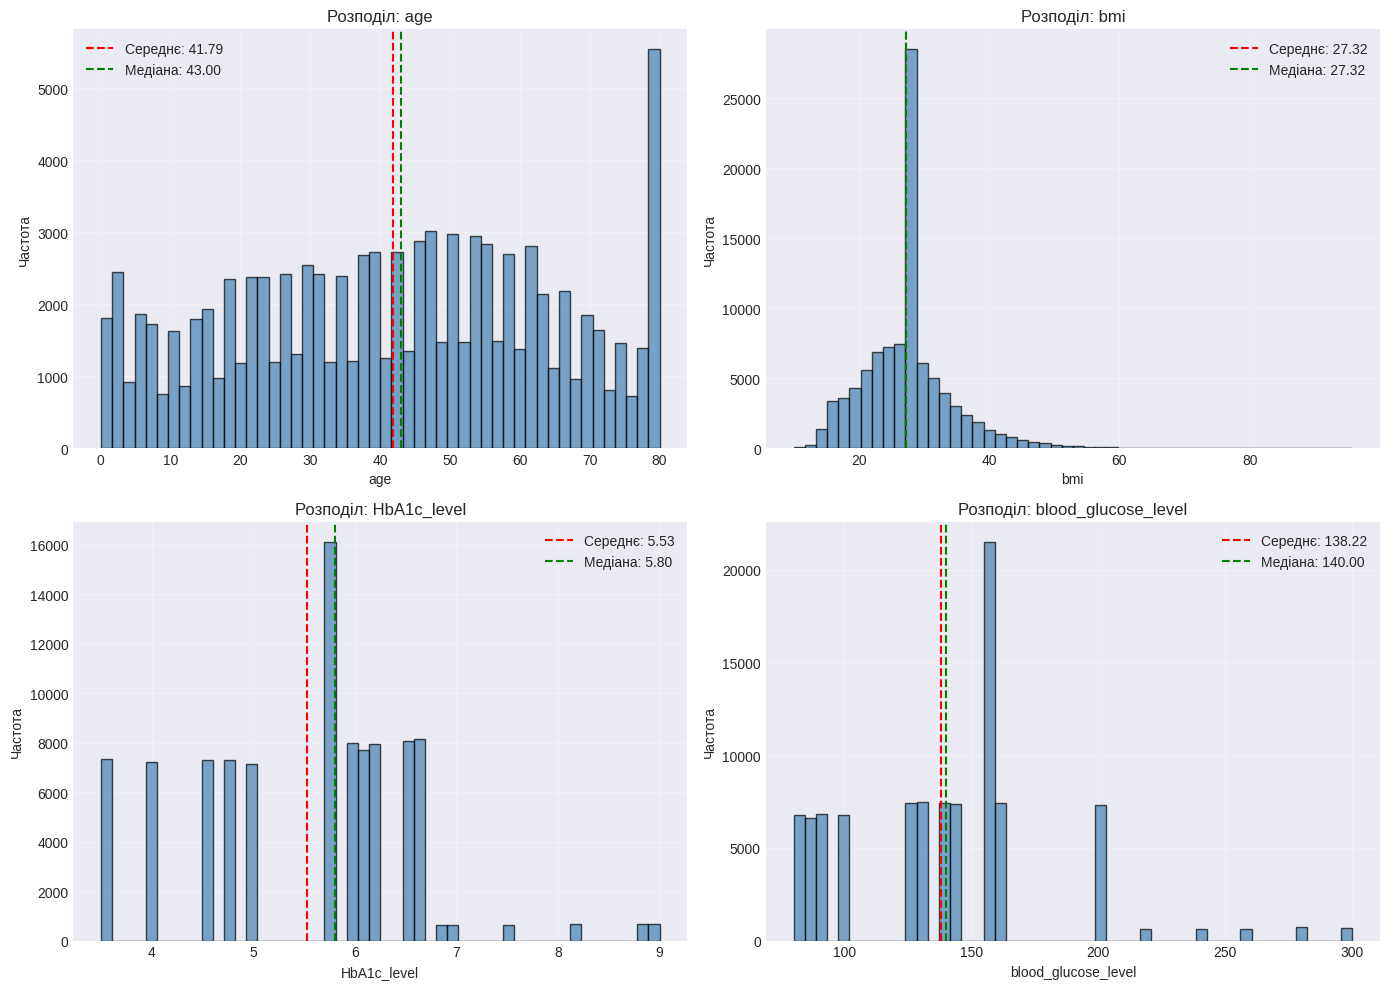


Коефіцієнти асиметрії (Skewness):
age: -0.062 (симетричний)
bmi: 1.024 (асиметричний)
HbA1c_level: -0.054 (симетричний)
blood_glucose_level: 0.836 (асиметричний)


In [ ]:
print("\n" + "="*60)
print("АНАЛІЗ РОЗПОДІЛІВ ТА БАЛАНСУВАННЯ КЛАСІВ")
print("="*60)

# Цільова змінна - баланс класів
target_counts = df['diabetes'].value_counts()
print("\nРозподіл цільової змінної:")
print(f"0 (немає діабету): {target_counts[0]} ({target_counts[0]/len(df)*100:.2f}%)")
print(f"1 (є діабет): {target_counts[1]} ({target_counts[1]/len(df)*100:.2f}%)")

# Візуалізація балансу класів
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Кругова діаграма
axes[0].pie(target_counts, labels=['Немає діабету', 'Діабет'], autopct='%1.1f%%',
            colors=['lightgreen', 'salmon'], startangle=90)
axes[0].set_title('Баланс класів', fontsize=14)

# Стовпчикова діаграма
sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[1], palette=['lightgreen', 'salmon'])
axes[1].set_title('Розподіл класів', fontsize=14)
axes[1].set_xlabel('Діабет (0 - ні, 1 - так)', fontsize=12)
axes[1].set_ylabel('Кількість', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Аналіз симетричності розподілу числових ознак
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Середнє: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Медіана: {df[col].median():.2f}')
    axes[i].set_title(f'Розподіл: {col}', fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Частота', fontsize=10)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Розрахунок асиметрії
print("\nКоефіцієнти асиметрії (Skewness):")
for col in numerical_cols:
    skewness = df[col].skew()
    print(f"{col}: {skewness:.3f} {'(симетричний)' if abs(skewness) < 0.5 else '(асиметричний)'}")

In [ ]:
print("\n" + "="*60)
print("ПІДГОТОВКА ДАНИХ ДЛЯ МОДЕЛЮВАННЯ")
print("="*60)

# Кодування категоріальних ознак
df_processed = df.copy()

# Кодування gender (male, female, other)
df_processed['gender'] = le_gender.fit_transform(df_processed['gender'])

# Кодування smoking_history
df_processed['smoking_history'] = le_smoking.fit_transform(df_processed['smoking_history'])

# Визначення ознак та цільової змінної
X = df_processed.drop('diabetes', axis=1)
y = df_processed['diabetes']

print(f"Ознаки: {list(X.columns)}")
print(f"Розмір X: {X.shape}")
print(f"Розмір y: {y.shape}")

# Розділення на тренувальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nТренувальна вибірка: {X_train.shape[0]} зразків")
print(f"Тестова вибірка: {X_test.shape[0]} зразків")

# Масштабування ознак
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nМасштабування виконано успішно!")


ПІДГОТОВКА ДАНИХ ДЛЯ МОДЕЛЮВАННЯ
Ознаки: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Розмір X: (96146, 8)
Розмір y: (96146,)

Тренувальна вибірка: 76916 зразків
Тестова вибірка: 19230 зразків

Масштабування виконано успішно!



НАВЧАННЯ БАЗОВИХ МОДЕЛЕЙ

----------------------------------------
Модель: LogisticRegression
----------------------------------------
Accuracy: 0.9594
Precision: 0.8670
Recall: 0.6380
F1-score: 0.7351

Класифікаційний звіт:
               precision    recall  f1-score   support

Немає діабету       0.97      0.99      0.98     17534
       Діабет       0.87      0.64      0.74      1696

     accuracy                           0.96     19230
    macro avg       0.92      0.81      0.86     19230
 weighted avg       0.96      0.96      0.96     19230



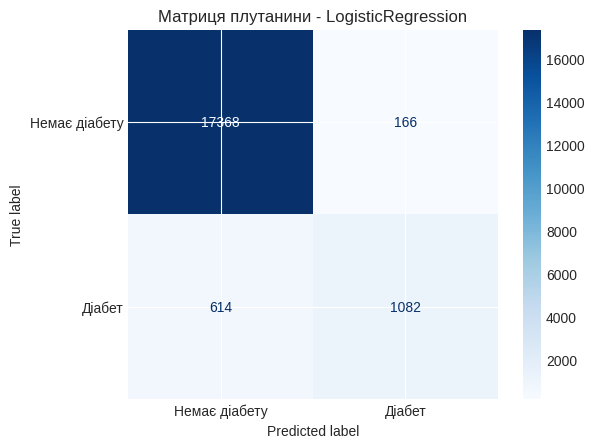


----------------------------------------
Модель: RidgeClassifier
----------------------------------------
Accuracy: 0.9398
Precision: 0.9838
Recall: 0.3225
F1-score: 0.4858

Класифікаційний звіт:
               precision    recall  f1-score   support

Немає діабету       0.94      1.00      0.97     17534
       Діабет       0.98      0.32      0.49      1696

     accuracy                           0.94     19230
    macro avg       0.96      0.66      0.73     19230
 weighted avg       0.94      0.94      0.93     19230



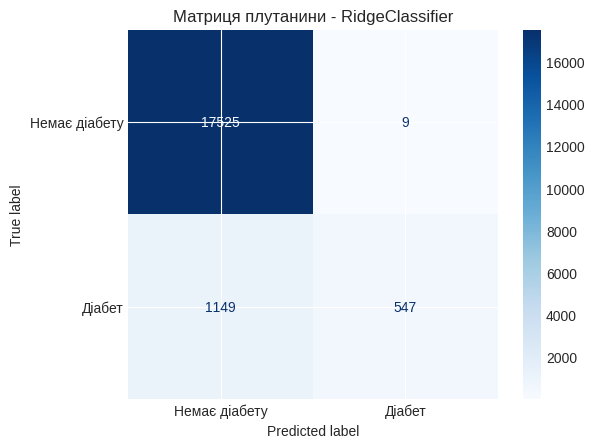


----------------------------------------
Модель: SGDClassifier
----------------------------------------
Accuracy: 0.9596
Precision: 0.9323
Recall: 0.5849
F1-score: 0.7188

Класифікаційний звіт:
               precision    recall  f1-score   support

Немає діабету       0.96      1.00      0.98     17534
       Діабет       0.93      0.58      0.72      1696

     accuracy                           0.96     19230
    macro avg       0.95      0.79      0.85     19230
 weighted avg       0.96      0.96      0.96     19230



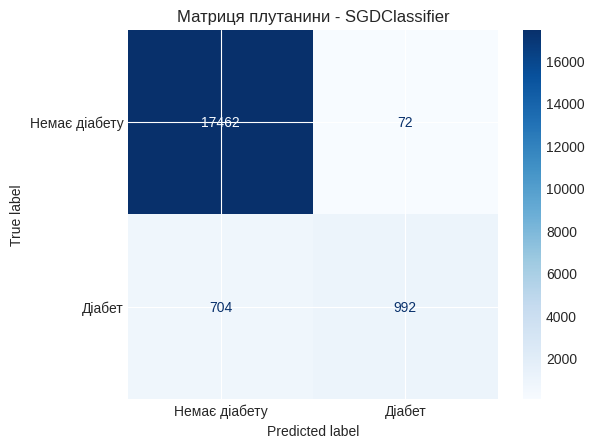


----------------------------------------
Модель: SVC
----------------------------------------
Accuracy: 0.9629
Precision: 0.9730
Recall: 0.5955
F1-score: 0.7388

Класифікаційний звіт:
               precision    recall  f1-score   support

Немає діабету       0.96      1.00      0.98     17534
       Діабет       0.97      0.60      0.74      1696

     accuracy                           0.96     19230
    macro avg       0.97      0.80      0.86     19230
 weighted avg       0.96      0.96      0.96     19230



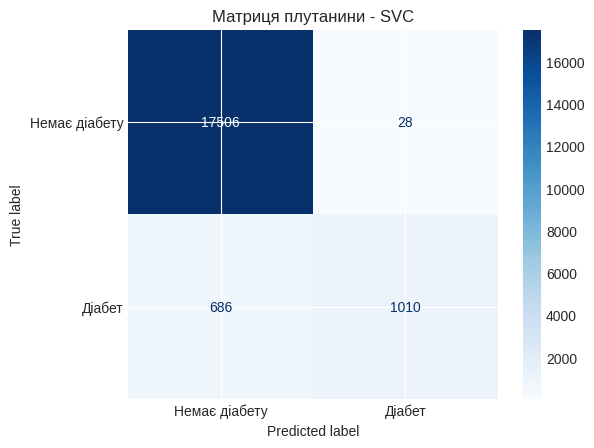

In [ ]:
print("\n" + "="*60)
print("НАВЧАННЯ БАЗОВИХ МОДЕЛЕЙ")
print("="*60)

# Словник моделей
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'RidgeClassifier': RidgeClassifier(random_state=42),
    'SGDClassifier': SGDClassifier(random_state=42, max_iter=1000),
    'SVC': SVC(random_state=42, probability=True)
}

# Навчання та оцінка моделей
results = {}

for name, model in models.items():
    print(f"\n{'-'*40}")
    print(f"Модель: {name}")
    print(f"{'-'*40}")

    # Навчання
    model.fit(X_train_scaled, y_train)

    # Прогнозування
    y_pred = model.predict(X_test_scaled)

    # Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'model': model
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    # Класифікаційний звіт
    print("\nКласифікаційний звіт:")
    print(classification_report(y_test, y_pred, target_names=['Немає діабету', 'Діабет']))

    # Матриця плутанини
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Немає діабету', 'Діабет'])
    disp.plot(cmap='Blues')
    plt.title(f'Матриця плутанини - {name}', fontsize=12)
    plt.show()

In [ ]:
print("\n" + "="*60)
print("ПІДБІР ОПТИМАЛЬНИХ ПАРАМЕТРІВ (GridSearchCV)")
print("="*60)

# Вибір найкращої моделі з попереднього етапу
# За F1-score обираємо найкращу модель
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = results[best_model_name]['model']
print(f"\nНайкраща базова модель: {best_model_name}")

# Визначення сітки параметрів для кожної моделі
param_grids = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [1000]
    },
    'RidgeClassifier': {
        'alpha': [0.01, 0.1, 1, 10, 100],
        'solver': ['auto', 'svd', 'cholesky']
    },
    'SGDClassifier': {
        'alpha': [0.0001, 0.001, 0.01, 0.1],
        'penalty': ['l2', 'l1', 'elasticnet'],
        'learning_rate': ['optimal', 'adaptive'],
        'max_iter': [1000]
    },
    'SVC': {
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 1],
        'kernel': ['rbf', 'poly'],
        'probability': [True]
    }
}

# Використання GridSearchCV для найкращої моделі
print(f"\nВиконання GridSearchCV для {best_model_name}...")

param_grid = param_grids[best_model_name]

# Створення нового екземпляра моделі
if best_model_name == 'LogisticRegression':
    model_to_tune = LogisticRegression(random_state=42)
elif best_model_name == 'RidgeClassifier':
    model_to_tune = RidgeClassifier(random_state=42)
elif best_model_name == 'SGDClassifier':
    model_to_tune = SGDClassifier(random_state=42)
elif best_model_name == 'SVC':
    model_to_tune = SVC(random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=model_to_tune,
    param_grid=param_grid,
    cv=5,  # 5-кратна крос-валідація
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Пошук оптимальних параметрів...")
grid_search.fit(X_train_scaled, y_train)

# Виведення оптимальних параметрів
print(f"\n{'='*40}")
print("ОПТИМАЛЬНІ ПАРАМЕТРИ")
print(f"{'='*40}")
print(f"Найкраща модель: {grid_search.best_estimator_}")
print(f"\nНайкращі параметри: {grid_search.best_params_}")
print(f"Найкращий F1-score (CV): {grid_search.best_score_:.4f}")

# Результати всіх ітерацій
print(f"\nКількість комбінацій параметрів: {len(grid_search.cv_results_['params'])}")


ПІДБІР ОПТИМАЛЬНИХ ПАРАМЕТРІВ (GridSearchCV)

Найкраща базова модель: SVC

Виконання GridSearchCV для SVC...
Пошук оптимальних параметрів...
Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [ ]:
print("\n" + "="*60)
print("ОЦІНКА ОПТИМІЗОВАНОЇ МОДЕЛІ")
print("="*60)

# Найкраща модель
best_tuned_model = halving_cv.best_estimator_

# Прогнозування на тестовій вибірці
y_pred_tuned = best_tuned_model.predict(X_test_scaled)

# Метрики
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("\nМетрики оптимізованої моделі:")
print(f"Accuracy: {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall: {recall_tuned:.4f}")
print(f"F1-score: {f1_tuned:.4f}")

print("\nКласифікаційний звіт оптимізованої моделі:")
print(classification_report(y_test, y_pred_tuned, target_names=['Немає діабету', 'Діабет']))

# Матриця плутанини
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Немає діабету', 'Діабет'])
disp_tuned.plot(cmap='Greens')
plt.title(f'Матриця плутанини - {best_model_name} (оптимізована)', fontsize=12)
plt.show()

# Порівняння з базовою моделлю
print("\n" + "="*40)
print("ПОРІВНЯННЯ БАЗОВОЇ ТА ОПТИМІЗОВАНОЇ МОДЕЛІ")
print("="*40)

comparison = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Базова модель': [
        results[best_model_name]['accuracy'],
        results[best_model_name]['precision'],
        results[best_model_name]['recall'],
        results[best_model_name]['f1']
    ],
    'Оптимізована модель': [accuracy_tuned, precision_tuned, recall_tuned, f1_tuned]
})

display(comparison)

In [ ]:
print("\n" + "="*60)
print("ВИПАДКОВІ ЗАПИСИ З ТЕСТОВОЇ ВИБІРКИ")
print("="*60)

# Вибір 10 випадкових записів
np.random.seed(42)
random_indices = np.random.choice(len(X_test), 10, replace=False)

# Створення DataFrame з результатами
random_samples = X_test.iloc[random_indices].copy()
random_samples['Справжній_клас'] = y_test.iloc[random_indices].values
random_samples['Прогнозований_клас'] = best_tuned_model.predict(X_test_scaled[random_indices])

# Декодування категоріальних змінних для зрозумілого виведення
random_samples_display = random_samples.copy()

# Декодування gender
gender_mapping = {0: 'Female', 1: 'Male', 2: 'Other'}
random_samples_display['gender'] = random_samples_display['gender'].map(gender_mapping)

# Декодування smoking_history
smoking_mapping = dict(enumerate(le_smoking.classes_))
random_samples_display['smoking_history'] = random_samples_display['smoking_history'].map(smoking_mapping)

# Виведення результатів
print("\n10 випадкових записів з тестової вибірки:")
print("-"*80)

for i, idx in enumerate(random_indices):
    print(f"\nЗапис {i+1}:")
    print(f"  Вік: {random_samples_display.iloc[i]['age']:.1f}")
    print(f"  Стать: {random_samples_display.iloc[i]['gender']}")
    print(f"  ІМТ: {random_samples_display.iloc[i]['bmi']:.2f}")
    print(f"  Гіпертензія: {'Так' if random_samples_display.iloc[i]['hypertension'] == 1 else 'Ні'}")
    print(f"  Хвороби серця: {'Так' if random_samples_display.iloc[i]['heart_disease'] == 1 else 'Ні'}")
    print(f"  Історія куріння: {random_samples_display.iloc[i]['smoking_history']}")
    print(f"  Рівень HbA1c: {random_samples_display.iloc[i]['HbA1c_level']:.2f}")
    print(f"  Рівень глюкози: {random_samples_display.iloc[i]['blood_glucose_level']:.1f}")
    print(f"  Справжній клас: {'Діабет' if random_samples_display.iloc[i]['Справжній_клас'] == 1 else 'Немає діабету'}")
    print(f"  Прогнозований клас: {'Діабет' if random_samples_display.iloc[i]['Прогнозований_клас'] == 1 else 'Немає діабету'}")
    print(f"  {' Правильно' if random_samples_display.iloc[i]['Справжній_клас'] == random_samples_display.iloc[i]['Прогнозований_клас'] else ' Неправильно'}")

In [ ]:
print("\n" + "="*60)
print("ВИСНОВКИ ТА АНАЛІЗ ПЕРЕНАВЧАННЯ")
print("="*60)

# Аналіз перенавчання
print("\n1. АНАЛІЗ БАЛАНСУВАННЯ ДАНИХ:")
print(f"   - Клас 'немає діабету': {target_counts[0]} ({target_counts[0]/len(df)*100:.2f}%)")
print(f"   - Клас 'діабет': {target_counts[1]} ({target_counts[1]/len(df)*100:.2f}%)")
print(f"   - Дані незбалансовані: позитивних випадків лише {target_counts[1]/len(df)*100:.2f}%")

print("\n2. АНАЛІЗ КОРЕЛЯЦІЙ:")
high_corr = corr_with_target[abs(corr_with_target) > 0.2].drop('diabetes', errors='ignore')
print(f"   Ознаки з найвищою кореляцією з цільовою змінною:")
for feat, corr_val in high_corr.items():
    print(f"   - {feat}: {corr_val:.3f}")

print("\n3. РОЗПОДІЛ ОЗНАК:")
for col in numerical_cols:
    skewness = df[col].skew()
    print(f"   - {col}: асиметрія = {skewness:.3f} ({'симетричний' if abs(skewness) < 0.5 else 'асиметричний'})")

print("\n4. ПОРІВНЯННЯ МОДЕЛЕЙ:")
for name, metrics in results.items():
    print(f"   - {name}: F1-score = {metrics['f1']:.4f}")

print(f"\n5. НАЙКРАЩА МОДЕЛЬ: {best_model_name}")
print(f"   - F1-score (базова): {results[best_model_name]['f1']:.4f}")
print(f"   - F1-score (оптимізована): {f1_tuned:.4f}")
print(f"   - Покращення: {(f1_tuned - results[best_model_name]['f1'])*100:.2f}%")

print("\n6. АНАЛІЗ ПЕРЕНАВЧАННЯ:")
# Порівняння тренувальних та тестових метрик
y_train_pred = best_tuned_model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"   - Точність на тренувальній вибірці: {train_accuracy:.4f}")
print(f"   - Точність на тестовій вибірці: {test_accuracy:.4f}")
print(f"   - Різниця: {train_accuracy - test_accuracy:.4f}")

if train_accuracy - test_accuracy > 0.05:
    print("     Можливе перенавчання: різниця між тренувальною та тестовою точністю перевищує 5%")
else:
    print("    Перенавчання не виявлено: різниця між тренувальною та тестовою точністю в межах норми")

print("\n7. РЕКОМЕНДАЦІЇ:")
print("   - Використовувати методи балансування класів (SMOTE, class_weight)")
print("   - Збільшити розмір вибірки для класу 'діабет'")
print("   - Розглянути можливість використання ансамблевих методів")
print("   - Виконати додаткову інженерію ознак для покращення передбачувальної здатності")